# grahspj: DR16Q Photometry With Bandwagon and SVI

This notebook demonstrates a bulk quasar workflow:

- download the SDSS DR16Q value-added catalog from the Illinois quasar archive
- draw a reproducible sample of about 200 quasars
- query GALEX, SDSS, and AllWISE photometry with `bandwagon` through CDS XMatch
- convert matched magnitudes and errors into long-form flux-density photometry
- fit each quasar SED with the `grahspj` SVI/MAP path

The default fit settings are intentionally light enough for a demo. Increase `SVI_STEPS` and rerun the fitting cells for production-quality MAP solutions.


## Prerequisites

This notebook assumes:

- you are running from `grahspj/notebooks/`
- `grahspj` dependencies are installed
- the sibling `bandwagon` package exists at `../../bandwagon/src`, or `bandwagon` is installed in your environment
- internet access is available for the catalog download and CDS XMatch calls
- a valid DSPS SSP file is available; by default this notebook looks for `../../jaxqsofit/tempdata.h5`

The DR16Q catalog URL used here is:

`http://quasar.astro.illinois.edu/paper_data/DR16Q/dr16q_prop_May01_2024.fits.gz`


In [24]:
from pathlib import Path
import sys

import astropy.units as u
import matplotlib.pyplot as plt
import numpy as np
from astropy.coordinates import SkyCoord
from astropy.table import Table
from astropy.utils.data import download_file
from tqdm.auto import tqdm

project_root = Path.cwd().resolve().parent
grahspj_src = project_root / "src"
bandwagon_src = project_root.parent / "bandwagon" / "src"
for path in (grahspj_src, bandwagon_src):
    if path.is_dir() and str(path) not in sys.path:
        sys.path.insert(0, str(path))

from bandwagon import DEFAULT_CATALOGS, matches_to_photometry, xmatch_catalogs
from grahspj.config import AGNConfig, FilterSet, FitConfig, GalaxyConfig, InferenceConfig, LikelihoodConfig, Observation, PhotometryData
from grahspj.core import GRAHSPJ
from grahspj.mplstyle import style_path

plt.style.use(style_path())


In [25]:
DR16Q_URL = "http://quasar.astro.illinois.edu/paper_data/DR16Q/dr16q_prop_May01_2024.fits.gz"
LOCAL_DR16Q_PATH = project_root.parent / "qvc" / "data" / "dr16q_prop_May01_2024.fits"
SAMPLE_SIZE = 20
RANDOM_SEED = 20260419
SVI_STEPS = 250
SVI_LEARNING_RATE = 5e-3
MIN_BANDS_TO_FIT = 5

# Set this lower while iterating locally, or keep it at SAMPLE_SIZE for the full demo.
N_FIT = SAMPLE_SIZE

# Keep noisier W3/W4 points in the demo while still dropping extreme catalog rows.
MAX_MAG_ERR = 1.0

FILTER_ORDER = {
    "FUV_galex": 0,
    "NUV_galex": 1,
    "u_sdss": 2,
    "g_sdss": 3,
    "r_sdss": 4,
    "i_sdss": 5,
    "z_sdss": 6,
    "W1": 7,
    "W2": 8,
    "W3": 9,
    "W4": 10,
}

# CDS XMatch defaults cover GALEX FUV/NUV, SDSS ugriz, and AllWISE W1-W4.
DEFAULT_CATALOGS


{'galex_ais': 'II/335/galex_ais',
 'sdss_dr16': 'V/154/sdss16',
 'allwise': 'II/328/allwise'}

## Download DR16Q


In [26]:
if LOCAL_DR16Q_PATH.is_file():
    catalog_path = LOCAL_DR16Q_PATH
else:
    catalog_path = Path(download_file(DR16Q_URL, cache=True, show_progress=True))

dr16q = Table.read(catalog_path)

print(f"Downloaded/read {len(dr16q):,} DR16Q rows")
print("First 25 columns:", dr16q.colnames[:25])
dr16q[:3]


Downloaded/read 750,414 DR16Q rows
First 25 columns: ['SDSS_NAME', 'PLATE', 'MJD', 'FIBERID', 'RA', 'DEC', 'OBJID', 'IF_BOSS_SDSS', 'Z_DR16Q', 'SOURCE_Z_DR16Q', 'Z_FIT', 'Z_SYS', 'Z_SYS_ERR', 'EBV', 'SN_MEDIAN_ALL', 'CONTI_FIT', 'CONTI_FIT_ERR', 'CONTI_STAT', 'FEII_UV', 'FEII_UV_ERR', 'FEII_UV_EW', 'FEII_UV_EW_ERR', 'FEII_OPT', 'FEII_OPT_ERR', 'FEII_OPT_EW']


SDSS_NAME,PLATE,MJD,FIBERID,RA,DEC,OBJID,IF_BOSS_SDSS,Z_DR16Q,SOURCE_Z_DR16Q,Z_FIT,Z_SYS,Z_SYS_ERR,EBV,SN_MEDIAN_ALL,CONTI_FIT,CONTI_FIT_ERR,CONTI_STAT,FEII_UV,FEII_UV_ERR,FEII_UV_EW,FEII_UV_EW_ERR,FEII_OPT,FEII_OPT_ERR,FEII_OPT_EW,FEII_OPT_EW_ERR,LOGL1350,LOGL1350_ERR,LOGL1700,LOGL1700_ERR,LOGL2500,LOGL2500_ERR,LOGL3000,LOGL3000_ERR,LOGL5100,LOGL5100_ERR,HALPHA,HALPHA_BR,NII6585,SII6718,HBETA,HBETA_BR,HEII4687,HEII4687_BR,OIII5007,OIII5007C,CAII3934,OII3728,NEV3426,MGII,MGII_BR,CIII_ALL,CIII_BR,SIIII1892,ALIII1857,NIII1750,CIV,HEII1640,HEII1640_BR,SIIV_OIV,OI1304,LYA,NV1240,HALPHA_ERR,HALPHA_BR_ERR,NII6585_ERR,SII6718_ERR,HBETA_ERR,HBETA_BR_ERR,HEII4687_ERR,HEII4687_BR_ERR,OIII5007_ERR,OIII5007C_ERR,CAII3934_ERR,OII3728_ERR,NEV3426_ERR,MGII_ERR,MGII_BR_ERR,CIII_ALL_ERR,CIII_BR_ERR,SIIII1892_ERR,ALIII1857_ERR,NIII1750_ERR,CIV_ERR,HEII1640_ERR,HEII1640_BR_ERR,SIIV_OIV_ERR,OI1304_ERR,LYA_ERR,NV1240_ERR,HA_COMP_STAT,HB_COMP_STAT,MGII_COMP_STAT,CIII_COMP_STAT,CIV_COMP_STAT,SIIV_COMP_STAT,LYA_COMP_STAT,CAII_LOC_STAT,OII_LOC_STAT,NEV_LOC_STAT,LOGLBOL,LOGLBOL_ERR,LOGMBH_HB,LOGMBH_HB_ERR,LOGMBH_MGII,LOGMBH_MGII_ERR,LOGMBH_CIV,LOGMBH_CIV_ERR,LOGMBH,LOGMBH_ERR,LOGLEDD_RATIO,LOGLEDD_RATIO_ERR,ZSYS_LINES,ZSYS_LINES_ERR,FHOST_5100
bytes18,int64,int64,int64,float64,float64,bytes20,bytes10,float64,bytes12,float64,float64,float64,float64,float64,float64[5],float64[5],float64[2],float64[3],float64[3],float64,float64,float64[3],float64[3],float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64[6],float64[6],float64[6],float64[6],float64[6],float64[6],float64[6],float64[6],float64[6],float64[6],float64[6],float64[6],float64[6],float64[6],float64[6],float64[6],float64[6],float64[6],float64[6],float64[6],float64[6],float64[6],float64[6],float64[6],float64[6],float64[6],float64[6],float64[6],float64[6],float64[6],float64[6],float64[6],float64[6],float64[6],float64[6],float64[6],float64[6],float64[6],float64[6],float64[6],float64[6],float64[6],float64[6],float64[6],float64[6],float64[6],float64[6],float64[6],float64[6],float64[6],float64[6],float64[6],float64[6],float64[6],float64[2],float64[2],float64[2],float64[2],float64[2],float64[2],float64[2],float64[2],float64[2],float64[2],float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64[8],float64[8],float64
000000.15+353104.2,7750,58402,802,0.00062949892515,35.51784115297793,7750-58402-0802,BOSS,0.8454347848892212,PIPE,0.8454347848892212,0.8468670453717015,0.0007044541403759998,0.0697395445353172,24.46896743774414,32.474211446063066 .. 1.1700782037238387e-09,0.0819156633245121 .. 8.827395955795116e-11,2539.0 .. 1.292390919866146,1.07404643589454 .. 0.0038245348710971,0.0175810989755281 .. 0.0008462505935933,49.50266155075893,0.832250024359201,1.628461274732722 .. 0.0009306057513148,0.0809941893424105 .. 0.0002579149066365,65.84736750657055,4.1644908886792,0.0,-1.0,0.0,-1.0,45.54185880387371,0.0008403380059398557,45.5267738465181,0.0010950838660868,45.131616648515084,0.0063169152703643,0.0 .. 0.0,0.0 .. 0.0,0.0 .. 0.0,0.0 .. 0.0,4862.538395321536 .. 158.55024238933106,4862.538395321536 .. 158.55024238933106,4689.427798573922 .. 5.256554628016647,4700.330820051037 .. 4.925965707185849,5010.843991332857 .. 9.371869397882184,5010.425801363751 .. 6.4163712949978935,3937.1444692914392 .. 0.8134491509537051,3760.0130647203055 .. 0.380404315145008,3425.6988326222654 .. 2.0436293261041665,2802.3081094977 .. 28.006254362596195,2800.367805652372 .. 27.913558662949747,0.0 .. 0.0,0.0 .. 0.0,0.0 .. 0.0,0.0 .. 0.0,0.0 .. 0.0,0.0 .. 0.0,0.0 .. 0.0,0.0 .. 0.0,0.0 .. 0.0,0.0 .. 0.0,0.0 .. 0.0,0.0 .. 0.0,-1.0 .. -1.0,-1.0 .. -1.0,-1.0 .. -1.0,-1.0 .. -1.0,0.8508580893758335 .. 16.352596493763826,1.0505107547137411 .. 16.352596493763826,0.8640594351027175 .. 6.1380037415304285,9.77369611865788 .. 5.937657870978906,0.9556276476241692 .. 1.582362151536266,1.038570249894292 .. 1.680477222879276,4.45808484637314 .. 0.37398865844

In [27]:
ra = np.asarray(dr16q["RA"], dtype=float)
dec = np.asarray(dr16q["DEC"], dtype=float)
redshift = np.asarray(dr16q["Z_DR16Q"], dtype=float)
valid = np.isfinite(ra) & np.isfinite(dec) & np.isfinite(redshift) & (redshift > 0.0)

rng = np.random.default_rng(RANDOM_SEED)
valid_idx = np.flatnonzero(valid)
sample_idx = rng.choice(valid_idx, size=min(SAMPLE_SIZE, valid_idx.size), replace=False)
sample = dr16q[sample_idx]

raw_names = np.asarray([str(value).strip() for value in sample["SDSS_NAME"]], dtype=object)

# Use guaranteed-unique local IDs for grouping XMatch results. Catalog names are
# kept as metadata because some table columns can be blank or non-unique.
source_ids = np.asarray([f"DR16Q_{int(i)}" for i in sample_idx], dtype=object)

coords = SkyCoord(
    ra=np.asarray(sample["RA"], dtype=float) * u.deg,
    dec=np.asarray(sample["DEC"], dtype=float) * u.deg,
    frame="icrs",
)

sample_meta = {
    str(source_id): {
        "source_id": str(source_id),
        "catalog_name": str(raw_name),
        "row_index": int(row_index),
        "ra": float(row["RA"]),
        "dec": float(row["DEC"]),
        "redshift": float(row["Z_DR16Q"]),
    }
    for source_id, raw_name, row_index, row in zip(source_ids, raw_names, sample_idx, sample)
}

print("Using columns: ra='RA', dec='DEC', redshift='Z_DR16Q', id='SDSS_NAME'")
print(f"Sample size: {len(sample):,}")
print("First source IDs:", source_ids[:5].tolist())


Using columns: ra='RA', dec='DEC', redshift='Z_DR16Q', id='SDSS_NAME'
Sample size: 20
First source IDs: ['DR16Q_620092', 'DR16Q_414777', 'DR16Q_269369', 'DR16Q_633919', 'DR16Q_702174']


## Query Photometry With Bandwagon


In [28]:
# This cell performs three CDS XMatch requests: GALEX AIS, SDSS DR16, and AllWISE.
# If you are rerunning repeatedly, consider writing `photometry` to ECSV after the first successful run.
matches = xmatch_catalogs(coords, source_id=source_ids)

for key, table in matches.items():
    print(f"{key:10s}: {len(table):6d} matched rows; columns={table.colnames[:12]}")


galex_ais :      6 matched rows; columns=['angDist', 'source_id', 'ra', 'dec', 'RAJ2000', 'DEJ2000', 'name', 'objid', 'phID', 'Cat', 'RAfdeg', 'DEfdeg']
sdss_dr16 :     59 matched rows; columns=['angDist', 'source_id', 'ra', 'dec', 'objID', 'RA_ICRS', 'DE_ICRS', 'errHalfMaj', 'errHalfMin', 'errPosAng', 'mode', 'class']
allwise   :     15 matched rows; columns=['angDist', 'source_id', 'ra', 'dec', 'AllWISE', 'RAJ2000', 'DEJ2000', 'eeMaj', 'eeMin', 'eePA', 'W1mag', 'W2mag']


In [29]:
photometry = matches_to_photometry(matches, max_mag_err=MAX_MAG_ERR)
print(f"Long-form photometry rows: {len(photometry):,}")

if len(photometry):
    filters, filter_counts = np.unique(np.asarray(photometry["filter_name"], dtype=str), return_counts=True)
    print("Rows by filter:")
    for name, count in zip(filters, filter_counts):
        print(f"  {name:10s} {count:5d}")

photometry[:12]


Long-form photometry rows: 150
Rows by filter:
  FUV_galex      3
  NUV_galex      6
  W1            15
  W2            15
  W3             9
  W4             2
  g_sdss        20
  i_sdss        20
  r_sdss        20
  u_sdss        20
  z_sdss        20


source_id,catalog,band,filter_name,speclite_name,mag,mag_err,mag_system,flux_mjy,flux_err_mjy,psf_fwhm_arcsec,match_distance_arcsec
str12,str9,str3,str9,str11,float64,float64,str4,float64,float64,float64,float64
DR16Q_190303,galex_ais,NUV,NUV_galex,galex-nuv,22.972999572753906,0.3637999892234802,ab,0.002348693899837635,0.0007869819682770302,5.3,1.103487
DR16Q_21711,galex_ais,NUV,NUV_galex,galex-nuv,22.705699920654297,0.4242999851703644,ab,0.0030043206345075728,0.0011740726661616267,5.3,1.235987
DR16Q_414777,galex_ais,NUV,NUV_galex,galex-nuv,20.334199905395508,0.10109999775886536,ab,0.026689859448490054,0.002485267340815893,5.3,0.212698
DR16Q_425981,galex_ais,FUV,FUV_galex,galex-fuv,21.718299865722656,0.41370001435279846,ab,0.007459441332328518,0.0028422843161388643,4.3,2.752992
DR16Q_425981,galex_ais,NUV,NUV_galex,galex-nuv,21.58609962463379,0.33329999446868896,ab,0.008425319890801048,0.002586410088099163,5.3,2.752992
DR16Q_532802,galex_ais,FUV,FUV_galex,galex-fuv,22.076099395751953,0.4056999981403351,ab,0.00536520709970672,0.0020047821016141083,4.3,0.835204
DR16Q_532802,galex_ais,NUV,NUV_galex,galex-nuv,21.285400390625,0.1907999962568283,ab,0.01111388996500708,0.0019530804576923407,5.3,0.835204
DR16Q_667112,galex_ais,FUV,FUV_galex,galex-fuv,21.989900588989258,0.42419999837875366,ab,0.005808527011656538,0.002269406821039511,4.3,0.75321
DR16Q_667112,galex_ais,NUV,NUV_galex,galex-nuv,21.168699264526367,0.20340000092983246,ab,0.01237503805435769,0.0023183188888168276,5.3,0.75321


Sources with >= 5 bands: 20
Will fit: 20
First fit source bands: [np.str_('FUV_galex'), np.str_('NUV_galex'), np.str_('u_sdss'), np.str_('g_sdss'), np.str_('r_sdss'), np.str_('i_sdss'), np.str_('z_sdss'), np.str_('W1'), np.str_('W2'), np.str_('W3'), np.str_('W4')]


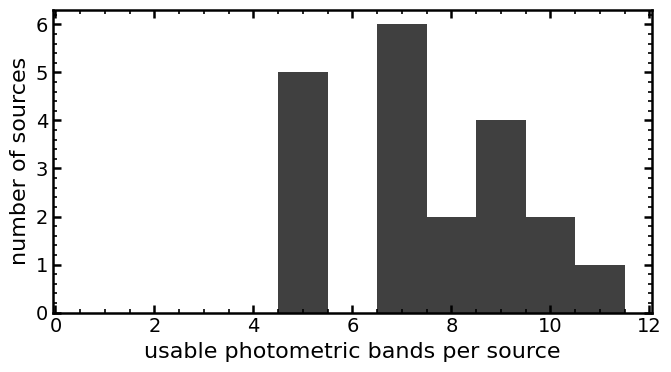

In [30]:
# Keep only sources with enough usable photometric bands for a constrained demo fit.
# Prefer examples with W4, then W3, then the largest number of bands so the
# notebook's displayed fit exercises the long-wavelength WISE bands when present.
phot_source_ids = np.asarray(photometry["source_id"], dtype=str) if len(photometry) else np.asarray([], dtype=str)
unique_ids, counts = np.unique(phot_source_ids, return_counts=True)
source_band_sets = {
    sid: set(np.asarray(photometry[phot_source_ids == sid]["filter_name"], dtype=str))
    for sid in unique_ids
}

def source_priority(source_id):
    bands = source_band_sets[str(source_id)]
    return (
        "W4" in bands,
        "W3" in bands,
        len(bands),
    )

fit_source_ids = [sid for sid, count in zip(unique_ids, counts) if count >= MIN_BANDS_TO_FIT]
fit_source_ids = sorted(fit_source_ids, key=source_priority, reverse=True)[:N_FIT]

print(f"Sources with >= {MIN_BANDS_TO_FIT} bands: {len(fit_source_ids):,}")
print(f"Will fit: {len(fit_source_ids):,}")
if fit_source_ids:
    first_bands = sorted(source_band_sets[fit_source_ids[0]], key=lambda name: FILTER_ORDER.get(name, 999))
    print("First fit source bands:", first_bands)

plt.figure(figsize=(7, 4))
plt.hist(counts, bins=np.arange(0.5, max(counts, default=0) + 1.5, 1.0), color="0.25")
plt.xlabel("usable photometric bands per source")
plt.ylabel("number of sources")
plt.tight_layout()


## Build `grahspj` Configurations


In [31]:
dsps_ssp_fn = project_root.parent / "jaxqsofit" / "tempdata.h5"
assert dsps_ssp_fn.is_file(), f"DSPS SSP file not found: {dsps_ssp_fn}"


def rows_for_source(source_id):
    mask = np.asarray(photometry["source_id"], dtype=str) == str(source_id)
    rows = photometry[mask]
    order = np.argsort([FILTER_ORDER.get(str(name), 999) for name in rows["filter_name"]])
    return rows[order]


def build_fit_config(source_id, rows):
    meta = sample_meta[str(source_id)]
    filter_names = [str(name) for name in rows["filter_name"]]
    fluxes = np.asarray(rows["flux_mjy"], dtype=float)
    errors = np.asarray(rows["flux_err_mjy"], dtype=float)

    # Avoid unrealistically tiny catalog errors in a heterogeneous multi-epoch SED.
    errors = np.maximum(errors, 0.03 * fluxes)

    return FitConfig(
        observation=Observation(
            object_id=str(source_id),
            redshift=float(meta["redshift"]),
            fit_redshift=False,
            ra=float(meta["ra"]),
            dec=float(meta["dec"]),
        ),
        photometry=PhotometryData(
            filter_names=filter_names,
            fluxes=fluxes.tolist(),
            errors=errors.tolist(),
            is_upper_limit=[False] * len(rows),
            psf_fwhm_arcsec=[float(value) for value in rows["psf_fwhm_arcsec"]],
        ),
        filters=FilterSet(
            speclite_names={str(row["filter_name"]): str(row["speclite_name"]) for row in rows},
            use_grahsp_database=False,
        ),
        galaxy=GalaxyConfig(
            dsps_ssp_fn=str(dsps_ssp_fn),
            n_wave=768,
        ),
        agn=AGNConfig(agn_type=1),
        likelihood=LikelihoodConfig(
            systematics_width=0.08,
            variability_uncertainty=True,
            use_host_capture_model=True,
        ),
        inference=InferenceConfig(
            map_steps=SVI_STEPS,
            learning_rate=SVI_LEARNING_RATE,
            seed=RANDOM_SEED,
        ),
        prior_config={
            "log_stellar_mass": {"loc": 10.5, "scale": 1.25},
            "fracAGN_5100": {"loc": 0.75, "scale": 0.2},
            "ebv_gal": {"scale": 0.2},
            "ebv_agn": {"scale": 0.2},
        },
    )

example_rows = rows_for_source(fit_source_ids[0]) if fit_source_ids else None
example_cfg = build_fit_config(fit_source_ids[0], example_rows) if fit_source_ids else None
print(example_cfg)


FitConfig(observation=Observation(object_id='DR16Q_532802', redshift=2.772, fit_redshift=False, redshift_err=0.0, ra=219.40452816237377, dec=4.7865969120349625, apply_mw_deredden=False), photometry=PhotometryData(filter_names=['FUV_galex', 'NUV_galex', 'u_sdss', 'g_sdss', 'r_sdss', 'i_sdss', 'z_sdss', 'W1', 'W2', 'W3', 'W4'], fluxes=[0.00536520709970672, 0.01111388996500708, 0.025422988254424135, 0.0598723019321077, 0.07677611619158324, 0.08433864419272702, 0.09899802479918769, 0.09451848144237794, 0.12128028020971397, 0.4296383535385609, 1.9895831339286354], errors=[0.0020047821016141083, 0.0019530804576923407, 0.001147356407963515, 0.0017961690579632308, 0.002303283485747497, 0.0025301593257818105, 0.0033736804103275484, 0.004962120100096141, 0.010164997009975987, 0.10723782846772047, 0.8136183715505652], is_upper_limit=[False, False, False, False, False, False, False, False, False, False, False], psf_fwhm_arcsec=[4.3, 5.3, 1.53, 1.44, 1.32, 1.26, 1.29, 6.08, 6.84, 7.36, 11.99], aper

## Fit With SVI

`GRAHSPJ.fit_map()` uses NumPyro `SVI` with an `AutoDelta` guide, so the result is a MAP estimate. The loop below runs that SVI path for every selected source and records a compact summary.


In [32]:
fit_summaries = []
failed_fits = []
example_fitter = None

for n, source_id in enumerate(tqdm(fit_source_ids, desc="SVI fits")):
    rows = rows_for_source(source_id)
    cfg = build_fit_config(source_id, rows)
    fitter = GRAHSPJ(cfg)
    try:
        map_result = fitter.fit_map(
            steps=SVI_STEPS,
            learning_rate=SVI_LEARNING_RATE,
            progress_bar=False,
        )
        summary = fitter.summary()
        loss = np.asarray(map_result.get("losses", []), dtype=float)
        fit_summaries.append(
            {
                "source_id": str(source_id),
                "redshift": float(cfg.observation.redshift),
                "n_bands": len(rows),
                "final_loss": float(loss[-1]) if loss.size else np.nan,
                "log_stellar_mass_fit": summary.get("log_stellar_mass_fit", np.nan),
                "fracAGN_5100_median": summary.get("fracAGN_5100_median", np.nan),
                "log_agn_bol_luminosity_median": summary.get("log_agn_bol_luminosity_median", np.nan),
            }
        )
        if example_fitter is None:
            example_fitter = fitter
    except Exception as exc:
        failed_fits.append({"source_id": str(source_id), "error": repr(exc)})

fit_summary = Table(rows=fit_summaries)
print(f"Successful fits: {len(fit_summary):,}")
print(f"Failed fits: {len(failed_fits):,}")
fit_summary[:10]


SVI fits:   0%|          | 0/20 [00:00<?, ?it/s]

Successful fits: 20
Failed fits: 0


source_id,redshift,n_bands,final_loss,log_stellar_mass_fit,fracAGN_5100_median,log_agn_bol_luminosity_median
str12,float64,int64,float64,float64,float64,float64
DR16Q_532802,2.772,11,21.196197611829476,9.959179209807061,nan,nan
DR16Q_117391,0.807,9,25.041312003271017,10.20249781906208,nan,nan
DR16Q_425981,1.879378,10,12.211552395852245,10.040801707048649,nan,nan
DR16Q_667112,0.9945856332778931,10,12.644298489487461,10.211132088326197,nan,nan
DR16Q_190303,1.636,9,13.436928623387864,10.176788227016864,nan,nan
DR16Q_21711,3.107,9,35.54401431002187,10.307376340866762,nan,nan
DR16Q_414777,1.283909,9,19.374228026804953,10.134315998403506,nan,nan
DR16Q_338184,0.988,8,22.829944097182185,10.34149849277326,nan,nan
DR16Q_620092,1.8598767518997192,8,19.324823962348244,10.638214908876494,nan,nan


In [33]:
if failed_fits:
    Table(rows=failed_fits)[:10]
else:
    print("No failed fits.")


No failed fits.


## Inspect One Fit


/Users/colinburke/research/grahspj/src/grahspj/plotting.py:218: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


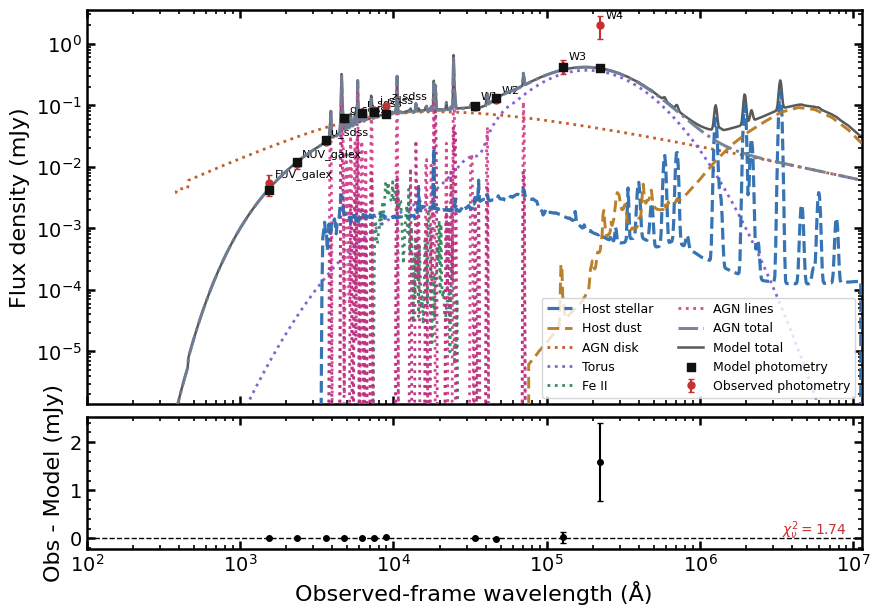

In [34]:
if example_fitter is None:
    raise RuntimeError("No successful fit to plot.")

pred = example_fitter.predict()
fig = example_fitter.plot_sed(show=True)


In [35]:
phot_wave = np.asarray([flt.effective_wavelength for flt in example_fitter.context.filters], dtype=float)
model_flux = np.asarray(pred["pred_fluxes"][0], dtype=float)

print("filter, eff_wave_A, obs_mJy, err_mJy, model_mJy")
for name, wave, obs, err, model in zip(
    example_fitter.config.photometry.filter_names,
    phot_wave,
    example_fitter.config.photometry.fluxes,
    example_fitter.config.photometry.errors,
    model_flux,
):
    print((name, wave, obs, err, model))


filter, eff_wave_A, obs_mJy, err_mJy, model_mJy
('FUV_galex', np.float64(1546.8691880021343), 0.00536520709970672, 0.0020047821016141083, np.float64(0.004181594216784844))
('NUV_galex', np.float64(2342.675196416365), 0.01111388996500708, 0.0019530804576923407, np.float64(0.011805680938009272))
('u_sdss', np.float64(3614.373573958611), 0.025422988254424135, 0.001147356407963515, np.float64(0.02706376394893364))
('g_sdss', np.float64(4749.2299689145675), 0.0598723019321077, 0.0017961690579632308, np.float64(0.06158128264636451))
('r_sdss', np.float64(6205.832237243061), 0.07677611619158324, 0.002303283485747497, np.float64(0.07639603748057504))
('i_sdss', np.float64(7525.622462977008), 0.08433864419272702, 0.0025301593257818105, np.float64(0.07854355777557433))
('z_sdss', np.float64(8947.384740828762), 0.09899802479918769, 0.0033736804103275484, np.float64(0.07310541987158165))
('W1', np.float64(34002.540444816936), 0.09451848144237794, 0.004962120100096141, np.float64(0.0967804294757971

## Save Optional Outputs

Uncomment these lines if you want local reusable artifacts from the demo run.


In [36]:
# output_dir = project_root / "notebook_outputs" / "05_dr16q_bandwagon_svi"
# output_dir.mkdir(parents=True, exist_ok=True)
# photometry.write(output_dir / "dr16q_sample_bandwagon_photometry.ecsv", overwrite=True)
# fit_summary.write(output_dir / "dr16q_sample_svi_summary.ecsv", overwrite=True)


## Notes

- GALEX and SDSS magnitudes are treated as AB magnitudes.
- AllWISE magnitudes are converted from Vega magnitudes with the standard WISE zero-points used by Bandwagon.
- This demo uses fixed catalog redshifts from DR16Q. To fit redshift, set `fit_redshift=True` and provide an uncertainty or redshift prior in the `FitConfig`.
- The raw XMatch tables are still available in `matches` if you need catalog quality flags beyond the normalized photometry table.
